In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
BASE_DIR = "../data"

In [3]:
def load_train_data(file_name: str) -> pd.DataFrame:
    """
    Load training data from a CSV file.

    Args:
        file_name (str): The name of the CSV file to load.

    Returns:
        pd.DataFrame: The loaded data.
    """
    return pd.read_csv(f"{BASE_DIR}/{file_name}", parse_dates=["date"])

In [4]:
train_df = load_train_data("train.csv")
train_df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [5]:
train_df.isna().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [6]:
train_df.describe()

,id,date,store_nbr,sales,onpromotion
count,3.000888e+06,3000888,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2015-04-24 08:27:04.703088384,2.750000e+01,3.577757e+02,2.602770e+00
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,2014-02-26 18:00:00,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2015-04-24 12:00:00,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,2016-06-19 06:00:00,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,2017-08-15 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02
std,8.662819e+05,NaN,1.558579e+01,1.101998e+03,1.221888e+01


In [7]:
print("Date range:", train_df["date"].min(), "to", train_df["date"].max())
print("Stores:", train_df["store_nbr"].nunique())
print("Family categories:", train_df["family"].nunique())
print("Family categories:", train_df["family"].unique())

Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00
Stores: 54
Family categories: 33
Family categories: ['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']


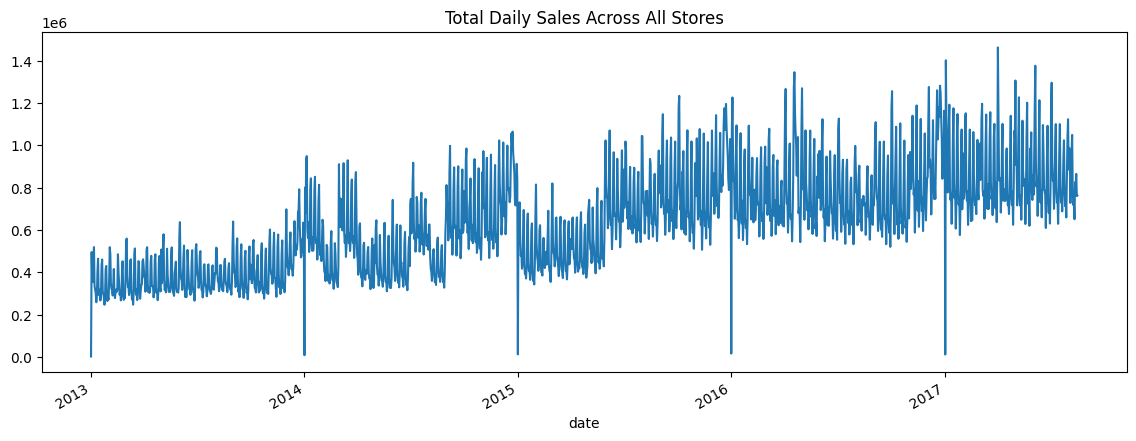

In [8]:
daily_sales = train_df.groupby("date")["sales"].sum()
daily_sales.plot(figsize=(14, 5), title="Total Daily Sales Across All Stores")
plt.show()

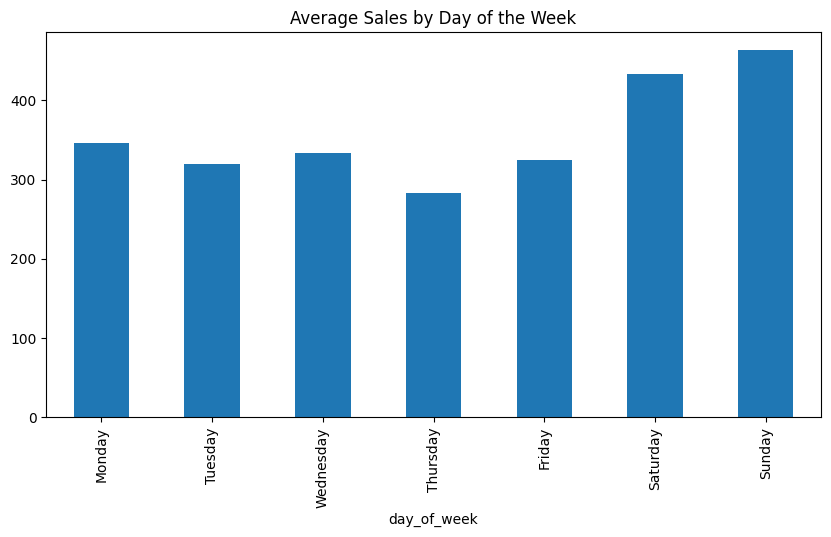

In [9]:
train_df["day_of_week"] = train_df["date"].dt.day_name()
train_df.groupby("day_of_week")["sales"].mean().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
).plot(kind="bar", figsize=(10, 5), title="Average Sales by Day of the Week")
plt.show()

In [10]:
train_df["day_of_week_num"] = train_df["date"].dt.dayofweek
train_df["month"] = train_df["date"].dt.month
train_df["year"] = train_df["date"].dt.year
train_df["is_weekend"] = train_df["day_of_week_num"].isin([5, 6]).astype(int)

train_df[["date", "day_of_week_num", "month", "year", "is_weekend"]].head()

,date,day_of_week_num,month,year,is_weekend
0,2013-01-01,1,1,2013,0
1,2013-01-01,1,1,2013,0
2,2013-01-01,1,1,2013,0
3,2013-01-01,1,1,2013,0
4,2013-01-01,1,1,2013,0


In [11]:
oil_df = load_train_data("oil.csv")
holidays_df = load_train_data("holidays_events.csv")
stores_df = pd.read_csv(f"{BASE_DIR}/stores.csv")

In [12]:
national_holidays = holidays_df[
    (holidays_df["locale"] == "National") & (holidays_df["transferred"] == False)
]["date"].unique()

train_df["is_holiday"] = train_df["date"].isin(national_holidays).astype(int)
train_df["is_holiday"].value_counts()

is_holiday
0    2758536
1     242352
Name: count, dtype: int64

In [13]:
train_df = train_df.merge(oil_df, on="date", how="left")
train_df["dcoilwtico"] = train_df["dcoilwtico"].ffill().bfill()
train_df[["date", "dcoilwtico"]].head()

,date,dcoilwtico
0,2013-01-01,93.14
1,2013-01-01,93.14
2,2013-01-01,93.14
3,2013-01-01,93.14
4,2013-01-01,93.14


In [14]:
train_df = train_df.merge(stores_df, on="store_nbr", how="left")
train_df[["store_nbr", "city", "state", "type", "cluster"]].drop_duplicates().head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
33,10,Quito,Pichincha,C,15
66,11,Cayambe,Pichincha,B,6
99,12,Latacunga,Cotopaxi,C,15
132,13,Latacunga,Cotopaxi,C,15


In [15]:
train_df = train_df.sort_values(["store_nbr", "family", "date"])
train_df["sales_lag_7"] = train_df.groupby(["store_nbr", "family"])["sales"].shift(7)
train_df[["store_nbr", "family", "date", "sales", "sales_lag_7"]].head(10)

,store_nbr,family,date,sales,sales_lag_7
0,1,AUTOMOTIVE,2013-01-01,0.0,NaN
1782,1,AUTOMOTIVE,2013-01-02,2.0,NaN
3564,1,AUTOMOTIVE,2013-01-03,3.0,NaN
5346,1,AUTOMOTIVE,2013-01-04,3.0,NaN
7128,1,AUTOMOTIVE,2013-01-05,5.0,NaN
8910,1,AUTOMOTIVE,2013-01-06,2.0,NaN
10692,1,AUTOMOTIVE,2013-01-07,0.0,NaN
12474,1,AUTOMOTIVE,2013-01-08,2.0,0.0
14256,1,AUTOMOTIVE,2013-01-09,2.0,2.0
16038,1,AUTOMOTIVE,2013-01-10,2.0,3.0


In [16]:
train_df["sales_lag_7"] = train_df["sales_lag_7"].fillna(0)

In [17]:
categorical_cols = ["family", "city", "state", "type"]
for col in categorical_cols:
    train_df[col] = train_df[col].astype("category")

In [18]:
cutoff_date = train_df["date"].max() - pd.Timedelta(days=15)

train_split = train_df[train_df["date"] <= cutoff_date]
val_split = train_df[train_df["date"] > cutoff_date]

print(train_split.shape, val_split.shape)

(2974158, 18) (26730, 18)


In [19]:
feature_cols = [
    "store_nbr", "family", "onpromotion", "day_of_week_num", "month", "year",
    "is_weekend", "is_holiday", "dcoilwtico", "city", "state", "type", "cluster",
    "sales_lag_7",
]
target_col = "sales"

X_train = train_split[feature_cols]
y_train = train_split[target_col]
X_val = val_split[feature_cols]
y_val = val_split[target_col]

In [20]:
import lightgbm as lgb
import numpy as np

model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
)

model.fit(
    X_train, np.log1p(y_train),
    categorical_feature=categorical_cols,
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.064753 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 894
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 14
[LightGBM] [Info] Start training from score 2.920052


LGBMRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

In [21]:
from sklearn.metrics import root_mean_squared_log_error

preds_log = model.predict(X_val)
preds = np.expm1(preds_log)
preds = np.clip(preds, 0, None)

rmsle = root_mean_squared_log_error(y_val, preds)
print(f"Validation RMSLE: {rmsle:.4f}")

Validation RMSLE: 0.4775


In [22]:
naive_preds = val_split["sales_lag_7"]
naive_rmsle = root_mean_squared_log_error(y_val, naive_preds)
print(f"Naive baseline (last week's sales) RMSLE: {naive_rmsle:.4f}")
print(f"Our model RMSLE: {rmsle:.4f}")

Naive baseline (last week's sales) RMSLE: 0.5690
Our model RMSLE: 0.4775


In [23]:
train_df["sales_rolling_mean_7"] = (
    train_df.groupby(["store_nbr", "family"])["sales"]
    .transform(lambda s: s.shift(1).rolling(window=7).mean())
)
train_df["sales_rolling_mean_7"] = train_df["sales_rolling_mean_7"].fillna(0)

train_df[["store_nbr", "family", "date", "sales", "sales_rolling_mean_7"]].head(12)

/tmp/ipykernel_146385/3770800142.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby(["store_nbr", "family"])["sales"]


,store_nbr,family,date,sales,sales_rolling_mean_7
0,1,AUTOMOTIVE,2013-01-01,0.0,0.000000
1782,1,AUTOMOTIVE,2013-01-02,2.0,0.000000
3564,1,AUTOMOTIVE,2013-01-03,3.0,0.000000
5346,1,AUTOMOTIVE,2013-01-04,3.0,0.000000
7128,1,AUTOMOTIVE,2013-01-05,5.0,0.000000
8910,1,AUTOMOTIVE,2013-01-06,2.0,0.000000
10692,1,AUTOMOTIVE,2013-01-07,0.0,0.000000
12474,1,AUTOMOTIVE,2013-01-08,2.0,2.142857
14256,1,AUTOMOTIVE,2013-01-09,2.0,2.428571
16038,1,AUTOMOTIVE,2013-01-10,2.0,2.428571


In [24]:
train_split = train_df[train_df["date"] <= cutoff_date]
val_split = train_df[train_df["date"] > cutoff_date]

feature_cols = feature_cols + ["sales_rolling_mean_7"]

X_train = train_split[feature_cols]
y_train = train_split[target_col]
X_val = val_split[feature_cols]
y_val = val_split[target_col]

model2 = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
model2.fit(X_train, np.log1p(y_train), categorical_feature=categorical_cols)

preds_log = model2.predict(X_val)
preds = np.clip(np.expm1(preds_log), 0, None)
rmsle2 = root_mean_squared_log_error(y_val, preds)
print(f"Model with rolling mean feature RMSLE: {rmsle2:.4f}")
print(f"Previous model RMSLE: {rmsle:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044672 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1149
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 15
[LightGBM] [Info] Start training from score 2.920052
Model with rolling mean feature RMSLE: 0.4101
Previous model RMSLE: 0.4775


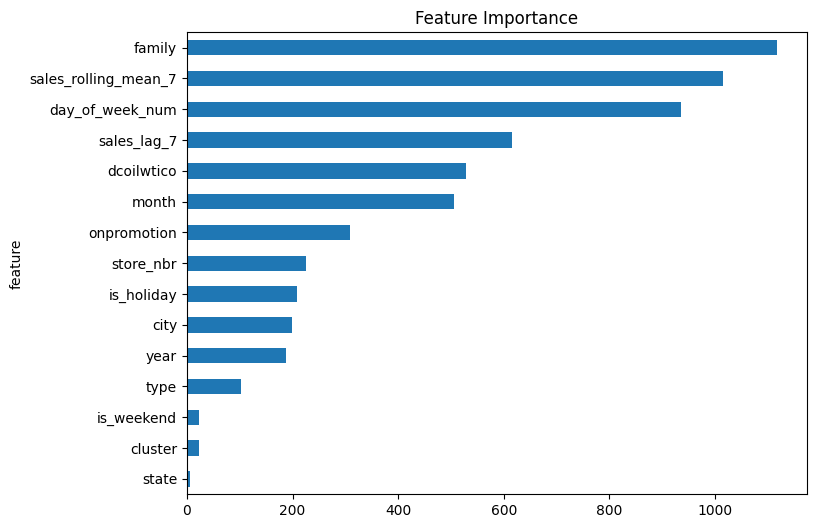

In [25]:
importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": model2.feature_importances_,
}).sort_values("importance", ascending=False)

importances.plot(kind="barh", x="feature", y="importance", figsize=(8, 6), legend=False, title="Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [26]:
test_df = load_train_data("test.csv")

test_df["day_of_week_num"] = test_df["date"].dt.dayofweek
test_df["month"] = test_df["date"].dt.month
test_df["year"] = test_df["date"].dt.year
test_df["is_weekend"] = test_df["day_of_week_num"].isin([5, 6]).astype(int)
test_df["is_holiday"] = test_df["date"].isin(national_holidays).astype(int)

test_df = test_df.merge(oil_df, on="date", how="left")
test_df["dcoilwtico"] = test_df["dcoilwtico"].ffill().bfill()

test_df = test_df.merge(stores_df, on="store_nbr", how="left")

last_features = (
    train_df.sort_values("date")
    .groupby(["store_nbr", "family"])
    .tail(1)[["store_nbr", "family", "sales_lag_7", "sales_rolling_mean_7"]]
)
test_df = test_df.merge(last_features, on=["store_nbr", "family"], how="left")

for col in categorical_cols:
    test_df[col] = test_df[col].astype("category")

test_df[feature_cols].isna().sum()

/tmp/ipykernel_146385/2376777040.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["store_nbr", "family"])


store_nbr               0
family                  0
onpromotion             0
day_of_week_num         0
month                   0
year                    0
is_weekend              0
is_holiday              0
dcoilwtico              0
city                    0
state                   0
type                    0
cluster                 0
sales_lag_7             0
sales_rolling_mean_7    0
dtype: int64

In [28]:
X_test = test_df[feature_cols]
test_preds_log = model2.predict(X_test)
test_preds = np.clip(np.expm1(test_preds_log), 0, None)

submission = pd.DataFrame({"id": test_df["id"], "sales": test_preds})
submission.to_csv("../outputs/submission.csv", index=False)
submission.head()

,id,sales
0,3000888,3.583885
1,3000889,0.029741
2,3000890,4.749723
3,3000891,2000.392665
4,3000892,0.029741


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>